In [218]:
import os
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from ipywidgets import widgets

plt.style.use("style.mplstyle")

In [219]:
output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

In [220]:
def func_eps_cos_psi(w: np.ndarray, delta: float, C: float) -> np.ndarray:
    return delta - (3.0 / 8.0) * w - C / w

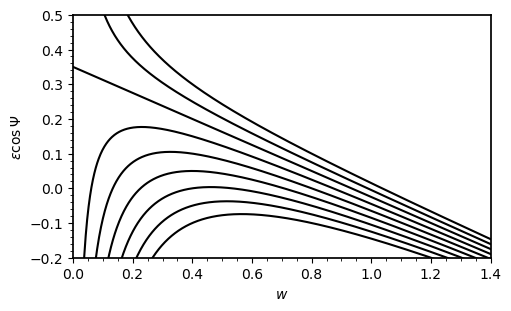

In [294]:
eps = 0.1
delta = 0.35

c_arr = np.arange(-0.04, 0.14, 0.02)

fig, ax = plt.subplots(figsize=(5, 3))
for c in c_arr:
    w = np.linspace(0.001, 1.6, 1000)
    eps_cos_psi = func_eps_cos_psi(w, delta, c)
    ax.plot(w, eps_cos_psi, color="black")
ax.set_ylim(-0.2, 0.5)
ax.set_xlim(0.0, 1.4)
ax.set_xlabel(r"$w$")
ax.set_ylabel(r"$\epsilon \cos{\Psi}$")
plt.savefig(os.path.join(output_dir, "fig_eps_cos_vs_w"))
plt.show()

In [295]:
def func_hamiltonian(w: np.ndarray, psi: np.ndarray, delta: float, eps: float) -> np.ndarray:
    return +delta * w - (3.0 / 8.0) * w**2 - eps * w * np.cos(psi)

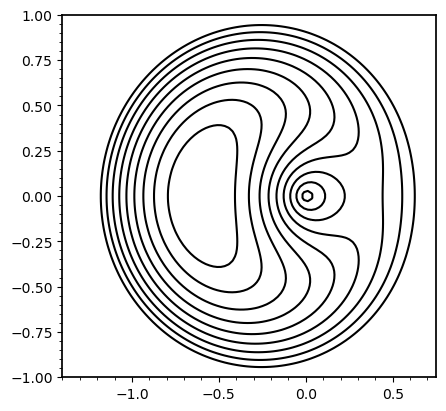

In [296]:
delta = 0.35
eps = 0.1

nbins = 100
grid_x = np.linspace(-1.4, 0.75, nbins)
grid_y = np.linspace(-1.0, 1.0, nbins)
grid_points = np.stack([np.ravel(c) for c in np.meshgrid(grid_x, grid_y, indexing="ij")], axis=-1)

x = grid_points[:, 0]
y = grid_points[:, 1]

w = np.sqrt(x**2 + y**2)
psi = np.arccos(x / w)

grid_values = func_hamiltonian(w, psi, delta=delta, eps=eps)
grid_values = grid_values.reshape((nbins, nbins))
grid_values -= np.min(grid_values)
grid_values /= np.max(grid_values)

levels = np.linspace(0.75, 1.0, 10)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.contour(grid_x, grid_y, grid_values.T, colors="black", levels=levels)
plt.savefig(os.path.join(output_dir, "fig_polar"))
plt.show()

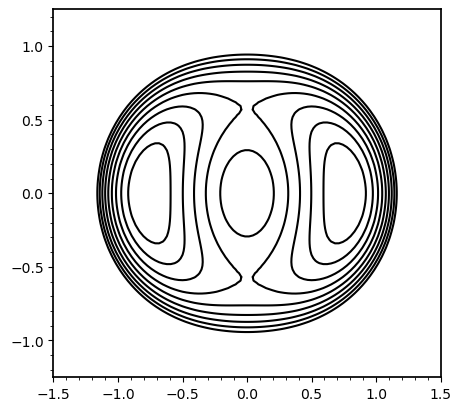

In [370]:
delta = 0.35
eps = 0.1

nbins = 100
grid_x = np.linspace(-1.5, 1.5, nbins)
grid_y = np.linspace(-1.25, 1.25, nbins)
grid_points = np.stack([np.ravel(c) for c in np.meshgrid(grid_x, grid_y, indexing="ij")], axis=-1)

x = grid_points[:, 0]
y = grid_points[:, 1]

psi = 2.0 * np.arctan(x / y)
w = 2.0 * x * y / np.sin(psi)

grid_values = func_hamiltonian(w, psi, delta=delta, eps=eps)
grid_values = grid_values.reshape((nbins, nbins))
grid_values -= np.min(grid_values)
grid_values /= np.max(grid_values)

levels = np.linspace(0.95, 1.0, 10)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.contour(grid_x, grid_y, grid_values.T, colors="black", levels=levels)
# ax.pcolormesh(grid_x, grid_y, grid_values.T, vmin=0.90, vmax=1.0)
plt.savefig(os.path.join(output_dir, "fig_xy"))
plt.show()